In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

epochs = 10
batch_size = 16
learning_rate = 0.001

Using: cuda


In [2]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),  
    transforms.ToTensor()
])

dataset = torchvision.datasets.ImageFolder(
    root="/kaggle/input/datasets/abhishekreddy27/busi-dataset/Dataset_BUSI_with_GT",
    transform=transform
)

print("Classes:", dataset.classes)

Classes: ['benign', 'malignant', 'normal']


In [3]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [4]:
import torchvision.models as models

model = models.resnet18(pretrained=True)

for param in model.parameters():
    param.requires_grad = False

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(dataset.classes))

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 154MB/s] 


In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=learning_rate)

In [6]:
train_losses = []
train_acc = []

for epoch in range(epochs):
    running_loss = 0.0
    correct = 0
    total = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    train_losses.append(epoch_loss)
    train_acc.append(epoch_acc)

    print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.2f}%")

Epoch 1/10 | Loss: 0.8227 | Acc: 61.73%
Epoch 2/10 | Loss: 0.5305 | Acc: 80.82%
Epoch 3/10 | Loss: 0.4804 | Acc: 80.74%
Epoch 4/10 | Loss: 0.4413 | Acc: 83.20%
Epoch 5/10 | Loss: 0.4207 | Acc: 82.96%
Epoch 6/10 | Loss: 0.3848 | Acc: 85.10%
Epoch 7/10 | Loss: 0.3766 | Acc: 85.42%
Epoch 8/10 | Loss: 0.3741 | Acc: 85.42%
Epoch 9/10 | Loss: 0.3422 | Acc: 86.37%
Epoch 10/10 | Loss: 0.3639 | Acc: 85.02%


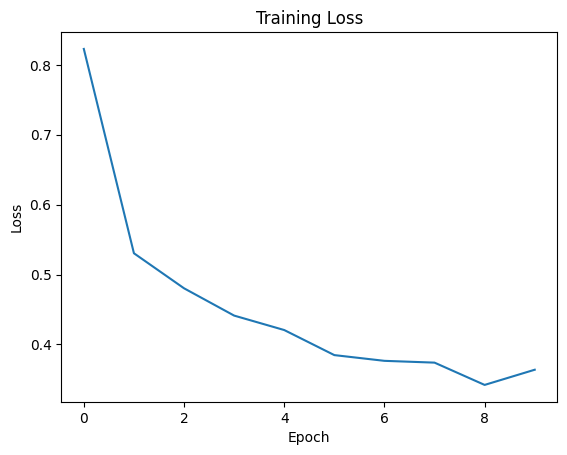

In [7]:
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

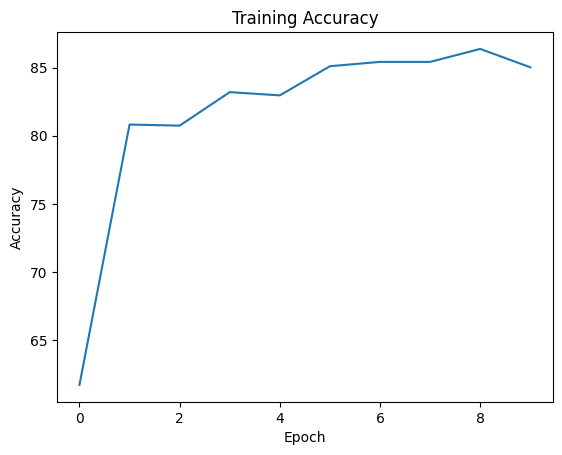

In [8]:
plt.plot(train_acc)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

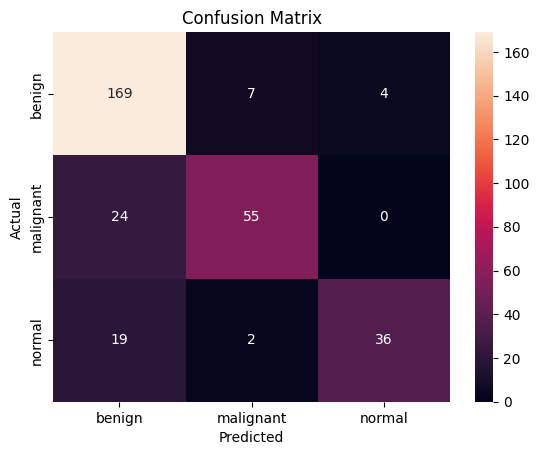

In [9]:
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=dataset.classes,
            yticklabels=dataset.classes)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [10]:
print(classification_report(all_labels, all_preds, target_names=dataset.classes))

              precision    recall  f1-score   support

      benign       0.80      0.94      0.86       180
   malignant       0.86      0.70      0.77        79
      normal       0.90      0.63      0.74        57

    accuracy                           0.82       316
   macro avg       0.85      0.76      0.79       316
weighted avg       0.83      0.82      0.82       316



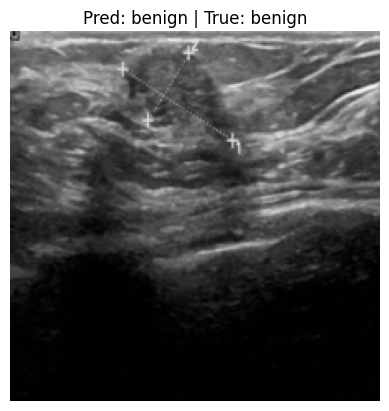

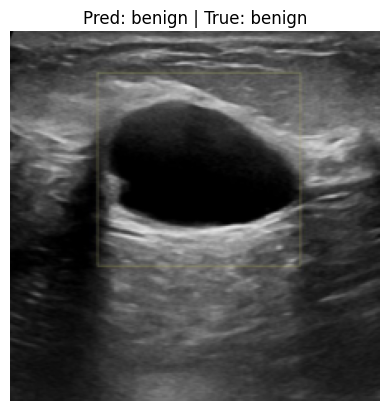

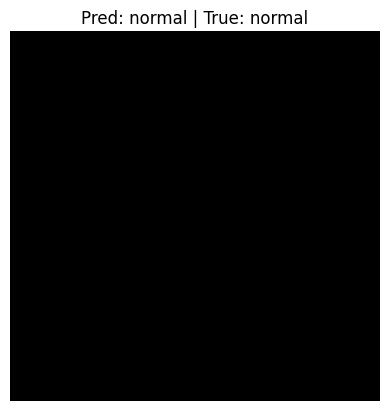

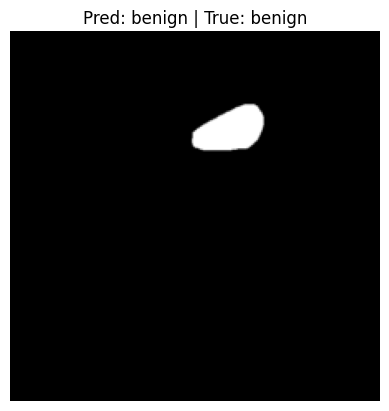

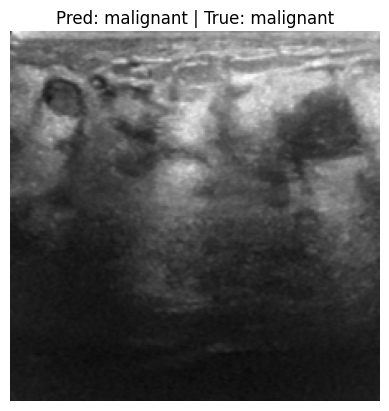

In [11]:
imgs, labels = next(iter(test_loader))
imgs = imgs.to(device)

outputs = model(imgs)
_, preds = torch.max(outputs, 1)

imgs = imgs.cpu()

for i in range(5):
    plt.imshow(np.transpose(imgs[i], (1,2,0)))
    plt.title(f"Pred: {dataset.classes[preds[i]]} | True: {dataset.classes[labels[i]]}")
    plt.axis('off')
    plt.show()